# **Bit-flip Error correction**
---
<img src="Imperial_logo.png" align = "left" width=200>
 <br>
 
- Copyright (c) Jack Jacquier, 2025. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9
---

In [1]:
import numpy as np
import matplotlib.pylab as plt
from math import comb

$\newcommand{\PP}{\mathbb{P}}$
$\newcommand{\pf}{\mathfrak{p}}$

We consider a bit $B$, taking values in $\{0,1\}$, that is transmitted through a channel.
This channel is noisy though, and there is a probability $\pf\in (0,1)$ that $B$ gets flipped.

We then adopt the following strategy: we make $2m+1$ (independent) copies of $B$ and use the *majority rule*, namely take as result whichever bit appears most often.

The probability that exactly $i \in \{0,\ldots,2m+1\}$ bits are flipped is equal to
$$
\mathbb{P}_{i} := \begin{pmatrix}
2m+1\\
i
\end{pmatrix}
\pf^i (1-\pf)^{2m+1-i},
$$
and therefore the probability that exactly at most $m \in \{0,\ldots,2m+1\}$ bits are flipped is equal to
$$
\sum_{i=0}^{m}\mathbb{P}_{i}.
$$


In [2]:
def probaError(p, m):
    """
    p: probability of a bit being flipped
    m: positive integer
    2m+1: number of bits sent

    returns the probability that more than m+1 bits are flipped
    """
    output = 0
    for i in range(m+1, 2*m+2):
        output += comb(2*m+1, i)*p**(i) * (1-p)**(2*m+1-i)
    return output

### Numerical results

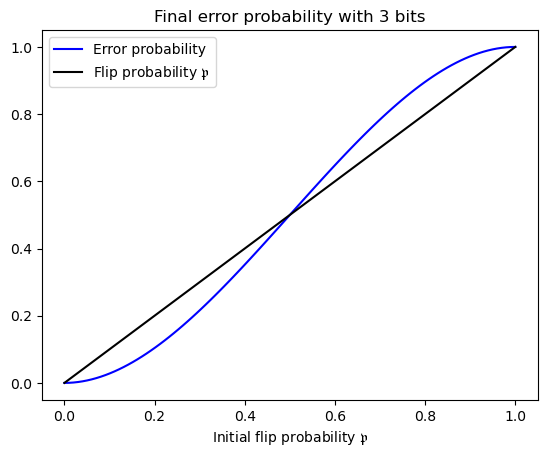

In [3]:
pp = np.linspace(0., 1., 100)
plt.plot(pp, [probaError(p, 1) for p in pp], 'b', label="Error probability")
plt.plot(pp, [p for p in pp], 'k', label=r'Flip probability $\mathfrak{p}$')
plt.xlabel(r'Initial flip probability $\mathfrak{p}$')
plt.legend(loc="best")
plt.title("Final error probability with 3 bits")
plt.show()

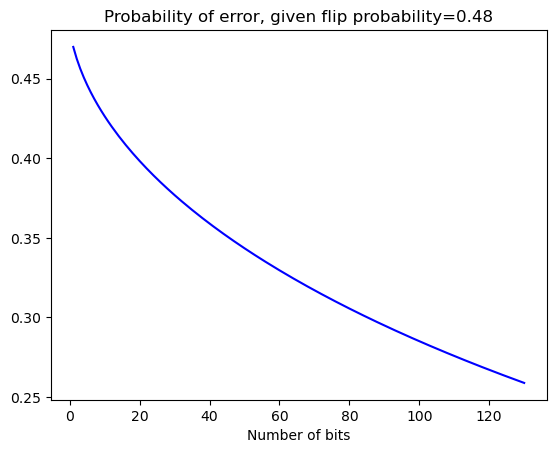

In [11]:
p = 0.48
mm = np.arange(1, 131)
plt.plot(mm, [probaError(p, m) for m in mm], 'b')
plt.xlabel("Number of bits")
plt.title("Probability of error, given flip probability=%.2f" %p)
plt.show()